<a href="https://colab.research.google.com/github/ammu1maru2/GOOGLE-SEARCH-DATA-ANALYSIS-PROJECT1/blob/main/GOOGLESEARCHDATAANALYSIS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

GOOGLE SEARCH DATA ANALYSIS PROJECT

In [4]:
pip install pytrends

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from pytrends.request import TrendReq


setup pytrend library and keyword define

In [6]:
pytrends = TrendReq(hl = 'en-us', tz = 360)
keyword = "cloud computing"

DATA REQUEST

In [7]:
pytrends.build_payload([keyword], cat = 0, timeframe = 'today 12-m', geo = '', gprop = '')

COUNTRY WISE INTEREST

In [8]:
region_data = pytrends.interest_by_region()
region_data = region_data.sort_values(by = keyword, ascending = False).head(15)


/tmp/ipython-input-544743215.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = region_data[keyword], y = region_data.index, palette = "Blues_d")


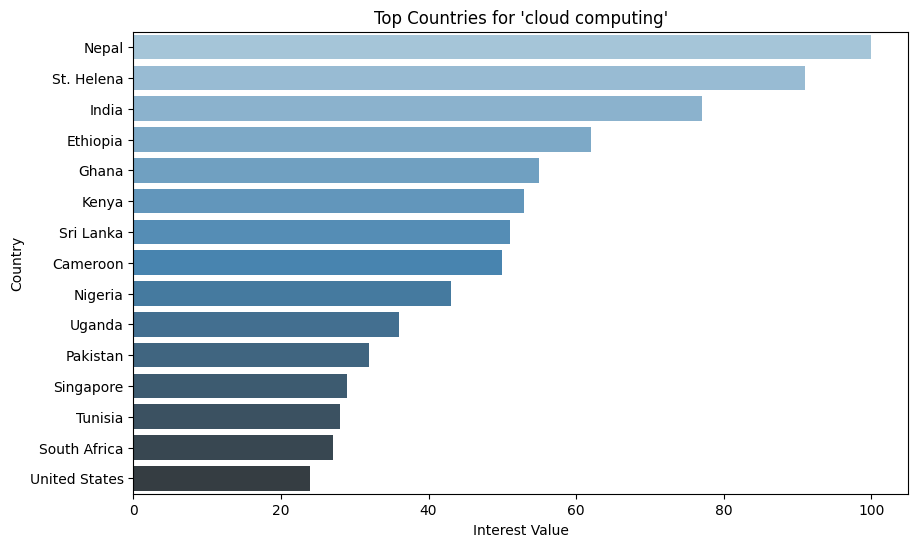

In [9]:
plt.figure(figsize=(10,6))
sns.barplot(x = region_data[keyword], y = region_data.index, palette = "Blues_d")
plt.title(f"Top Countries for '{keyword}'")
plt.xlabel("Interest Value")
plt.ylabel("Country")
plt.show()

WORLD MAP

In [10]:
region_data = region_data.reset_index()
fig = px.choropleth(region_data,
                    locations= 'geoName',
                    locationmode='country names',
                    color = keyword,
                    title=f"Search for Internet for '{keyword}'",
                    color_continuous_scale='Blues')
fig.show()

TIME WISE INTEREST

In [11]:
time_df = pytrends.interest_over_time()


/usr/local/lib/python3.12/dist-packages/pytrends/request.py:260: FutureWarning:

Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`



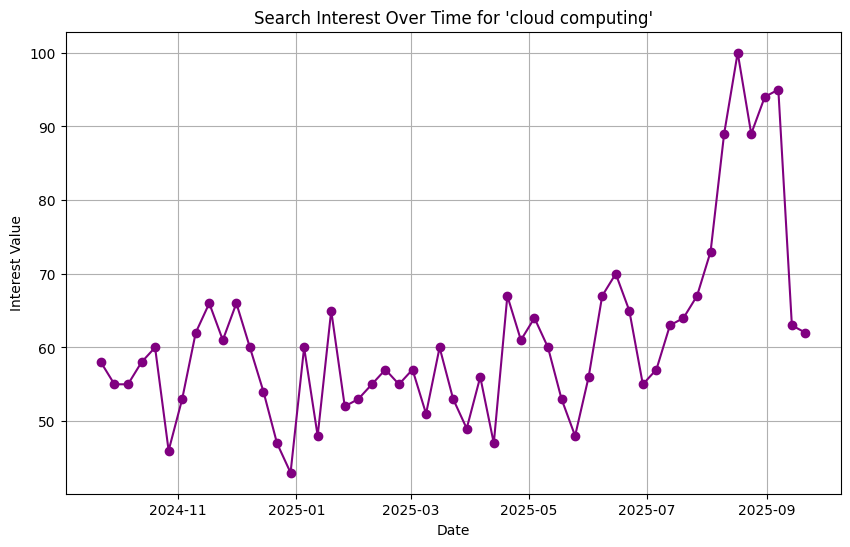

In [16]:
plt.figure(figsize=(10,6))
plt.plot(time_df.index, time_df[keyword], marker = 'o', color = 'purple')
plt.title(f"Search Interest Over Time for '{keyword}'")
plt.xlabel("Date")
plt.ylabel("Interest Value")
plt.grid(True)
plt.show()

MULTIPLE KEYWORD COMPARE

In [22]:
Kw_list = ["cloud computing","data science","machine learning"]
pytrends.build_payload(Kw_lisit, cat = 0, timeframe= 'today 12-m', geo = '', gprop= '')

/usr/local/lib/python3.12/dist-packages/pytrends/request.py:260: FutureWarning:

Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`



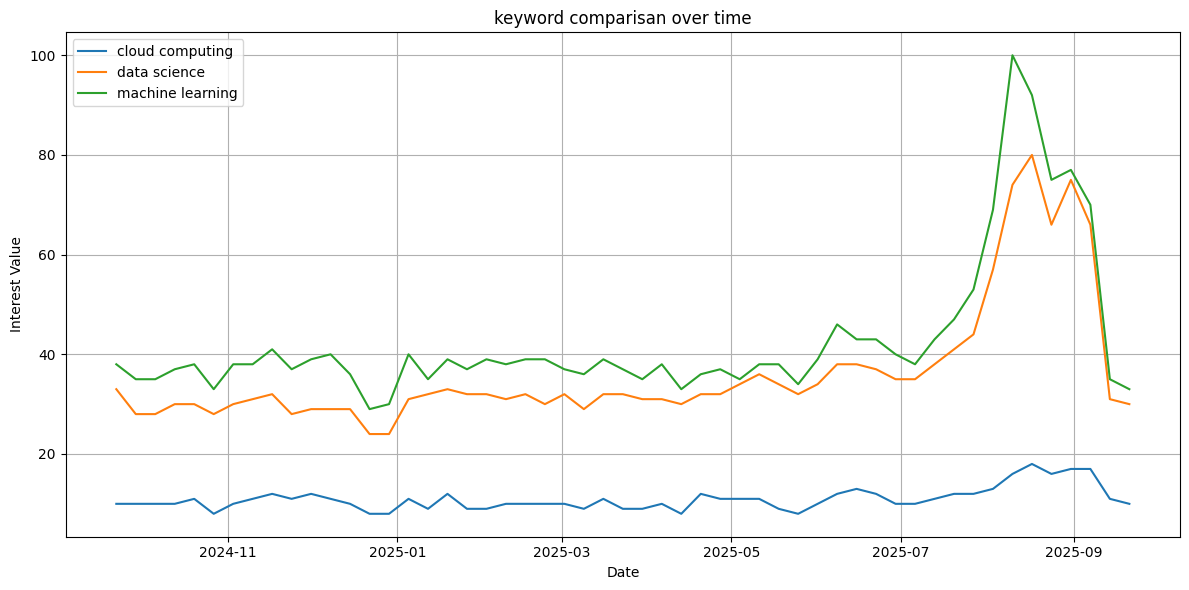

In [24]:
compare_df = pytrends.interest_over_time()

plt.figure(figsize=(12,6))
for Kw in Kw_list:
    plt.plot(compare_df.index, compare_df[Kw], label = Kw)

plt.title("keyword comparisan over time")
plt.xlabel("Date")
plt.ylabel("Interest Value")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()